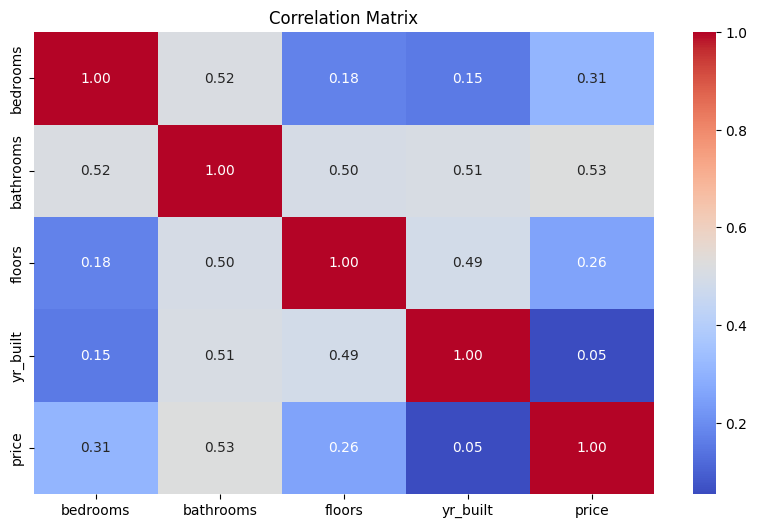

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset

df = pd.read_csv("./house_price.csv")

selected_columns = df[['bedrooms', 'bathrooms', 'floors', 'yr_built', 'price']]

# correlation matrix
correlation_matrix = selected_columns.corr()

# Visualize
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# choose best columns
X = df[['bedrooms', 'bathrooms', 'floors', 'yr_built']]  # Features
y = df['price']  # Target variable

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'R² Score: {r2}')

Mean Absolute Error: 197768.22805664377
R² Score: 0.32667134146410026


In [10]:
import pickle

# Save model using pickle
with open('linear_regression_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

In [14]:
print(X_test.head())

       bedrooms  bathrooms  floors  yr_built
735           4       2.25     2.0      1986
2830          5       3.00     1.0      1977
4106          4       2.50     2.0      1997
16218         3       3.50     2.0      1990
19964         3       2.50     2.0      2004
